In [ ]:
# Perceptron

import pandas as pd

In [ ]:
# Reading the dataset
df=pd.read_csv("dataset.csv")

# Viewing the top 5 items
print("Top 5 items:")
print(df.head())
print()

# Identifying the dimension of the dataset
print("Dimension:")
print(df.shape)
print()

# Identifying the existence of missing values
print("Missing Values:")
print(df.isna().sum())

Top 5 items:
   Variance  Skewness  Kurtosis  Entropy  Target
0   3.62160    8.6661   -2.8073 -0.44699       0
1   4.54590    8.1674   -2.4586 -1.46210       0
2   3.86600   -2.6383    1.9242  0.10645       0
3   3.45660    9.5228   -4.0112 -3.59440       0
4   0.32924   -4.4552    4.5718 -0.98880       0

Dimension:
(1372, 5)

Missing Values:
Variance    0
Skewness    0
Kurtosis    0
Entropy     0
Target      0
dtype: int64


In [ ]:
# Descriptive Statistics
for i in df:
  if i == 'Target': continue
  modevalue=df[i].mode().tolist()

  print(f"Variable Name: {i}")
  print(f"Mean: {df[i].mean()}")
  print(f"Median: {df[i].median()}")
  print(f"Mode Value: {modevalue}")
  print(f"Standard Deviation: {df[i].std()}")
  print(f"Range: {df[i].max()-df[i].min()}")
  print(f"Variance: {df[i].var()}")
  print(f"Count: {df[i].count()}")
  print()


Variable Name: Variance
Mean: 0.4337352570699707
Median: 0.49617999999999995
Mode Value: [0.5706]
Standard Deviation: 2.842762586278562
Range: 13.8669
Variance: 8.08129912194518
Count: 1372

Variable Name: Skewness
Mean: 1.9223531206413993
Median: 2.31965
Mode Value: [-4.4552]
Standard Deviation: 5.869046743694846
Range: 26.7247
Variance: 34.445709679675076
Count: 1372

Variable Name: Kurtosis
Mean: 1.3976271172667638
Median: 0.61663
Mode Value: [1.2421, 3.0895, 4.5718]
Standard Deviation: 4.310030090106595
Range: 23.2135
Variance: 18.576359377624268
Count: 1372

Variable Name: Entropy
Mean: -1.1916565200437317
Median: -0.58665
Mode Value: [-0.9888, -0.2957]
Standard Deviation: 2.1010131373596095
Range: 10.9977
Variance: 4.414256203357668
Count: 1372



In [ ]:
# To install the font library required for specific fonts
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf

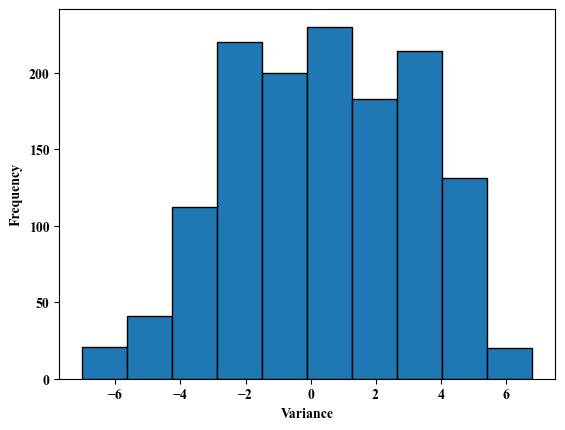

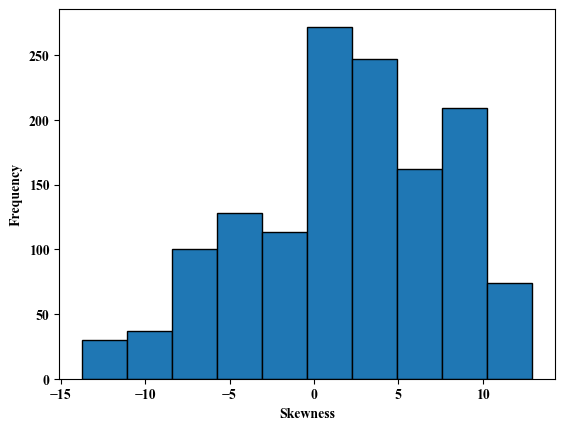

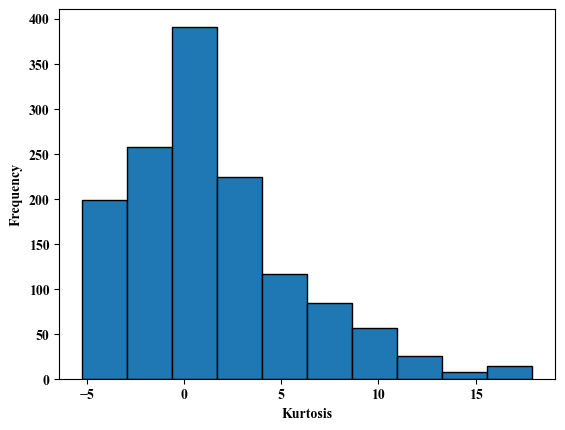

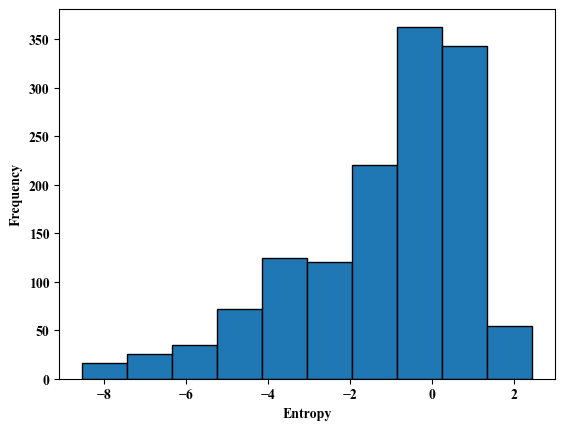

In [ ]:
# Applying the font globally
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/content/TimesNewRoman.ttf')
fm.fontManager.addfont('/content/times.ttf')
fm.fontManager.addfont('/content/timesbd.ttf')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Plotting Frequency vs feature

for i in df:
  if i == 'Target': continue
  plt.hist(df[i],edgecolor='black')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.savefig(f"{i}_hist.eps",dpi=600, format="eps")
  plt.show()


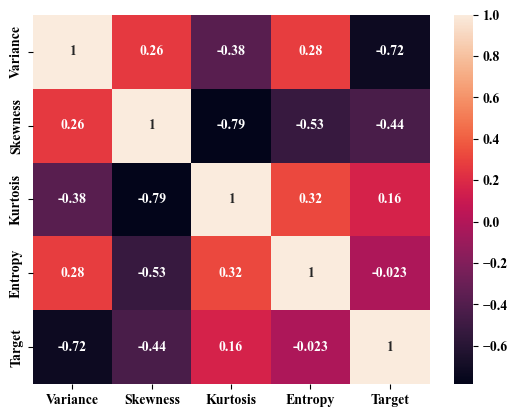

In [ ]:
# Plotting Correlation Heatmap

import seaborn as sns

corr_matrix=df.corr()
plt.figure()
sns.heatmap(corr_matrix,annot=True)
plt.savefig("correlation_heatmap.eps",dpi=600, format="eps")
plt.show()

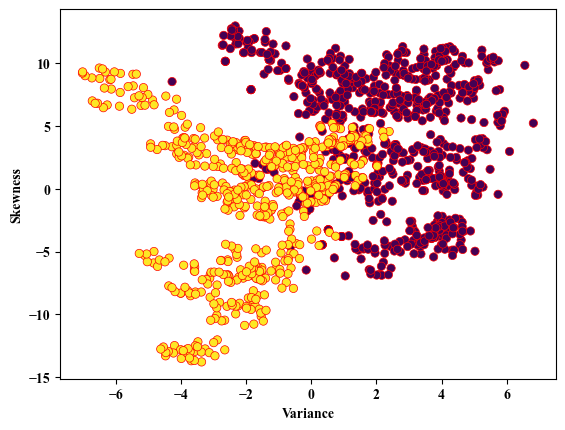

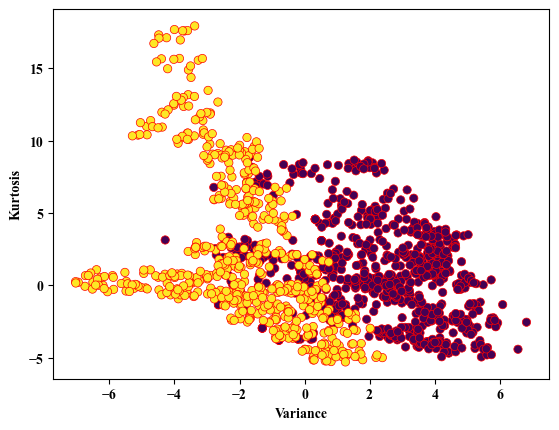

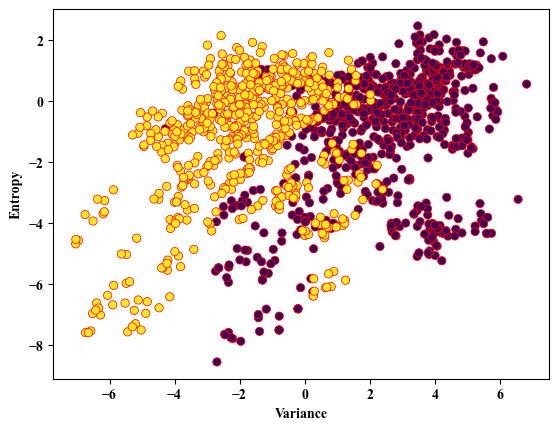

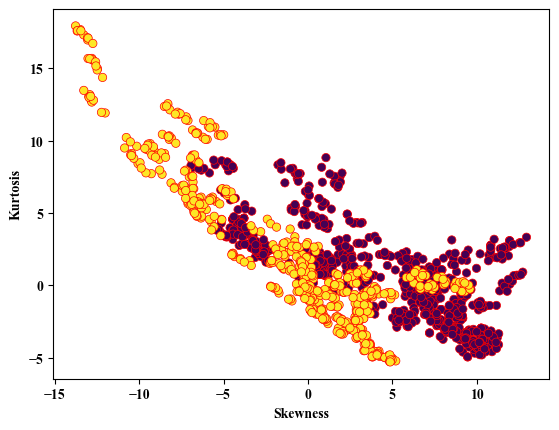

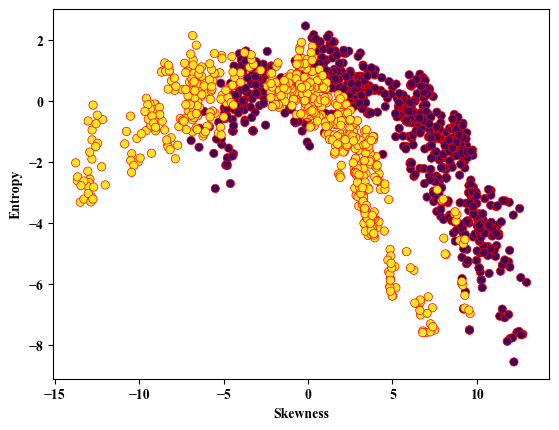

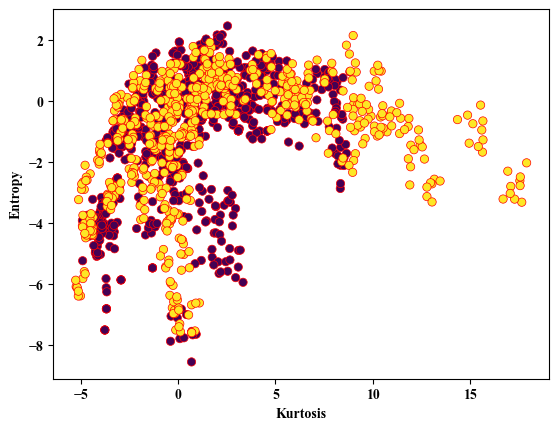

In [ ]:
# Plotting scatter

df_map = df[["Variance","Skewness","Kurtosis","Entropy"]]
L=[]
for i in df_map:
  for j in df_map:
    if i == j: continue
    if {i,j} in L: continue
    L.append({i,j})
    plt.figure()
    plt.scatter(df[i],df[j],c=df['Target'],edgecolors='red',linewidths=0.5)
    plt.xlabel(i)
    plt.ylabel(j)
    plt.savefig(f"{i}_{j}_scatter.eps",dpi=600, format="eps")
    plt.show()

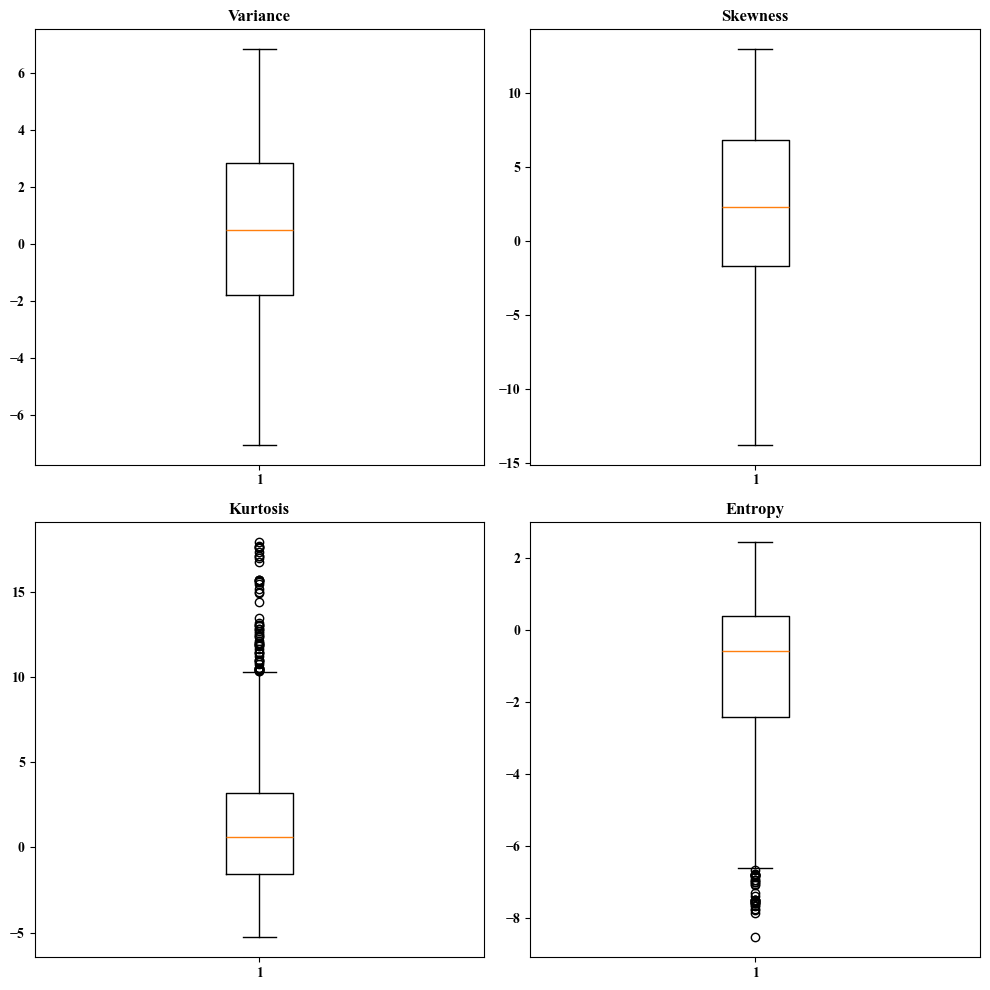

In [ ]:
# Box Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].boxplot(df['Variance'])
axes[0, 0].set_title('Variance')

axes[0, 1].boxplot(df['Skewness'])
axes[0, 1].set_title('Skewness')

axes[1, 0].boxplot(df['Kurtosis'])
axes[1, 0].set_title('Kurtosis')

axes[1, 1].boxplot(df['Entropy'])
axes[1, 1].set_title('Entropy')

plt.tight_layout()
plt.savefig("boxplot.eps",dpi=600, format="eps")
plt.show()


In [ ]:
#Normalizing the data features

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np


X=df.drop('Target',axis=1)
y=df['Target']

scaler=StandardScaler()
#X=scaler.fit_transform(X)

# Splitting the dataset to train and test (80% Train and 20% Test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

y_train=y_train.to_numpy()
y_test=y_test.to_numpy()

In [ ]:
# Implementing Perceptron

def Stepfn(z):
  return 1 if z>=0 else 0

w=np.zeros(4)
b=0
print(f"Initial weights: {w}")
print(f"Initial bias: {b}")

epochs=100
learning_rate=0.01


# Training Loop
print("\nTraining Loop:")

error_hist=[]
weight_hist=[]
bias_hist=[]

for i in range(epochs+1):

  mistake=0
  for j in range(len(X_train)):
    z=np.dot(X_train[j],w)+b
    y_pred=Stepfn(z) # Using Step Function

    error=y_train[j]-y_pred

    if error!=0:
      mistake+=1

    w=w+learning_rate*error*X_train[j]
    b=b+learning_rate*error

  if i%10==0:
    print(f"Epoch: {i}")
    print(f"Weights: {w}")
    print(f"Bias: {b}")
    print(f"Number of misclassifications: {mistake}")
    print()
  error_hist.append(mistake)
  bias_hist.append(b)
  weight_hist.append(w)

print("\n=======\nTraining Complete.")




print(f"\nFinal weights: {w}")
print(f"Final bias: {b}\n")





Initial weights: [0. 0. 0. 0.]
Initial bias: 0

Training Loop:
Epoch: 0
Weights: [-0.06920384 -0.06634441 -0.06529563 -0.00524322]
Bias: -0.03
Number of misclassifications: 47

Epoch: 10
Weights: [-0.14485453 -0.14504592 -0.11292681 -0.00241653]
Bias: -0.060000000000000005
Number of misclassifications: 20

Epoch: 20
Weights: [-0.15462523 -0.19195346 -0.14304725 -0.01137825]
Bias: -0.07
Number of misclassifications: 18

Epoch: 30
Weights: [-0.16460432 -0.19706686 -0.18111236 -0.01249806]
Bias: -0.09
Number of misclassifications: 18

Epoch: 40
Weights: [-1.90616182e-01 -2.22224255e-01 -1.74351325e-01  4.50545899e-05]
Bias: -0.09
Number of misclassifications: 19

Epoch: 50
Weights: [-0.20106937 -0.21738312 -0.20092241 -0.02134946]
Bias: -0.09999999999999999
Number of misclassifications: 15

Epoch: 60
Weights: [-0.20826523 -0.230299   -0.21311998 -0.01164836]
Bias: -0.10999999999999999
Number of misclassifications: 12

Epoch: 70
Weights: [-0.21249383 -0.23862536 -0.22780432 -0.01415968]
Bi

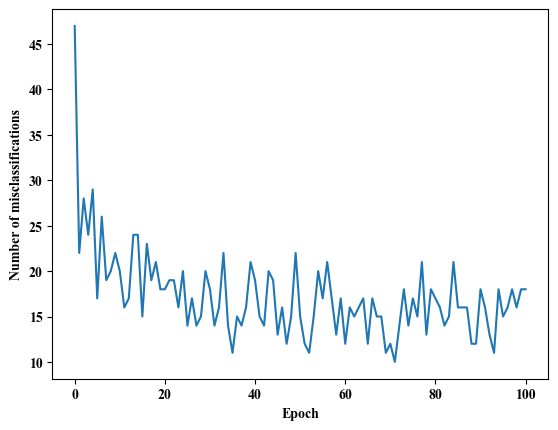

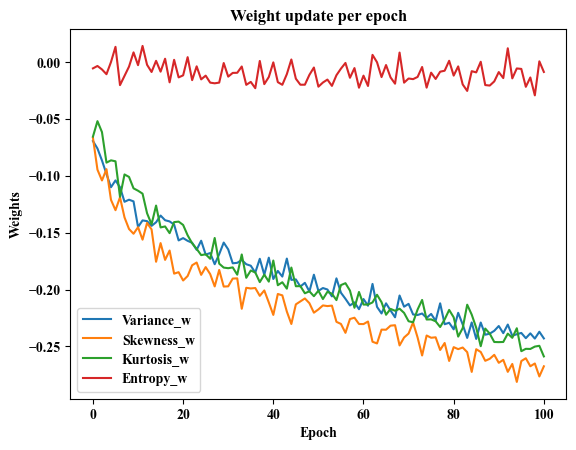

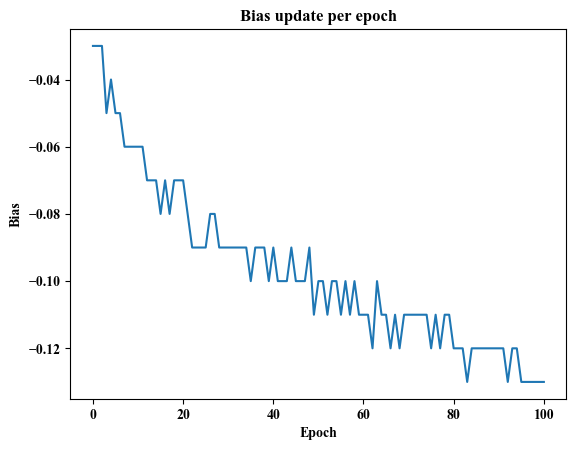

In [ ]:
# Evolution of weights, bias and number of mistakes

plt.figure()
plt.plot(error_hist)
plt.xlabel("Epoch")
plt.ylabel("Number of misclassifications")
plt.savefig("perceptron_convergence.eps", dpi=600, format="eps")
plt.show()

plt.figure()
plt.plot(weight_hist)
plt.legend(["Variance_w","Skewness_w","Kurtosis_w","Entropy_w"])
plt.xlabel("Epoch")
plt.ylabel("Weights")
plt.title("Weight update per epoch")
plt.savefig("weight_update.eps", dpi=600, format="eps")
plt.show()

plt.figure()
plt.plot(bias_hist)
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias update per epoch")
plt.savefig("bias_update.eps", dpi=600, format="eps")



In [ ]:
# Testing Loop

tp,tn,fp,fn=0,0,0,0

print("Testing Loop:")
for i in range(len(X_test)):
  z=np.dot(X_test[i],w)+b
  y_pred=Stepfn(z)
  if y_pred==y_test[i]:
    if y_pred==1: tp+=1
    else: tn+=1
  else:
    if y_pred==1: fp+=1
    else: fn+=1
print("\nTesting Complete.")
print(f"True Positive: {tp}")
print(f"True Negative: {tn}")
print(f"False Positive: {fp}")
print(f"False Negative: {fn}")




Testing Loop:

Testing Complete.
True Positive: 121
True Negative: 148
False Positive: 0
False Negative: 6


In [ ]:
# Results

accuracy=(tp+tn)/(tp+tn+fp+fn)
precision=tp/(tp+fp)
recall=tp/(tp+fn)
f1_score=2*precision*recall/(precision+recall)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")



Accuracy: 0.9781818181818182
Precision: 1.0
Recall: 0.952755905511811
F1 Score: 0.9758064516129031



Confusion Matrix:


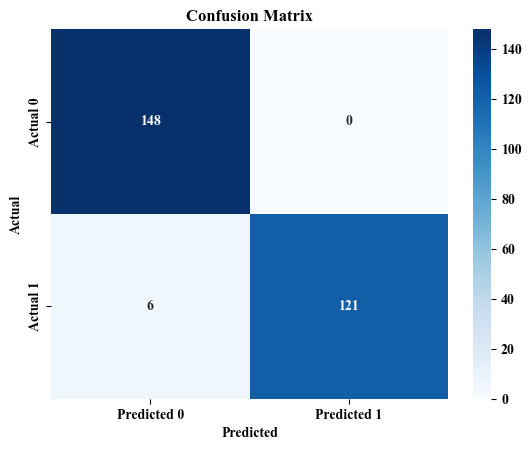

In [ ]:
# Generating Confusion matrix
import seaborn as sns
print("\nConfusion Matrix:")
cm=np.array([[tn,fp],[fn,tp]])
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.eps", dpi=600, format="eps")
plt.show()

In [ ]:
# Comparing various learning rates

lr=[0.001,0.01,0.1,0.5,1]
lrcmp=[]
wcmp=[]

for k in lr:
  error_hist=[]
  w_hist=[]
  w=np.zeros(4)
  b=0
  for i in range(epochs+1):

    mistake=0
    for j in range(len(X_train)):
      z=np.dot(X_train[j],w)+b
      y_pred=Stepfn(z)

      error=y_train[j]-y_pred

      if error!=0:
        mistake+=1

      w=w+k*error*X_train[j]
      b=b+k*error

    error_hist.append(mistake)
    w_hist.append(w)
  lrcmp.append(error_hist)
  wcmp.append(w_hist)
  print(f"Finished training with Learning Rate: {k}")

  print()


Finished training with Learning Rate: 0.001

Finished training with Learning Rate: 0.01

Finished training with Learning Rate: 0.1

Finished training with Learning Rate: 0.5

Finished training with Learning Rate: 1



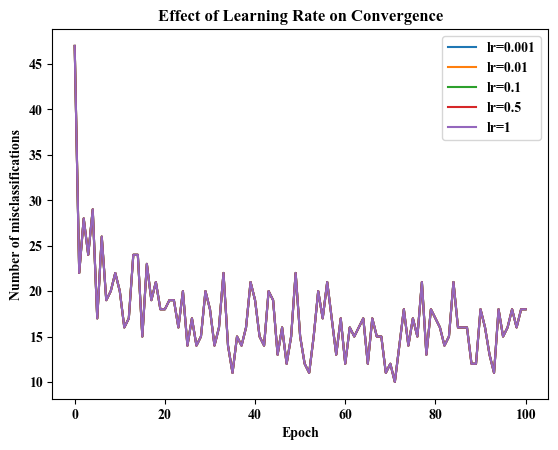

<Figure size 640x480 with 0 Axes>

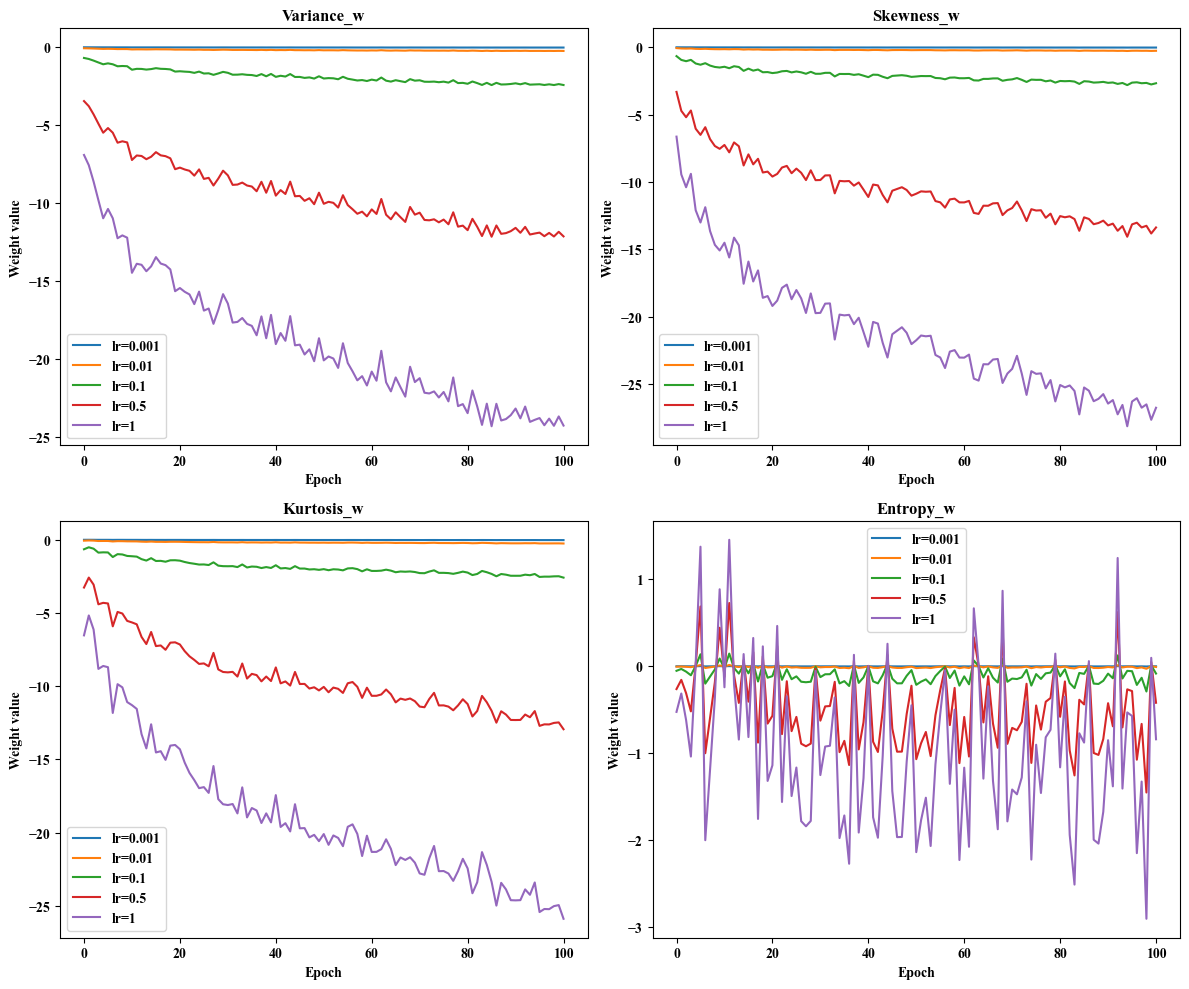

In [ ]:
# Comparing the outputs from different learning rates

plt.figure()
for k, hist in zip(lr, lrcmp):
    plt.plot(hist, label=f"lr={k}")
plt.xlabel("Epoch")
plt.ylabel("Number of misclassifications")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.savefig("lr_comparison.eps", dpi=600, format="eps")
plt.show()

plt.figure()
weight_names = ["Variance_w", "Skewness_w", "Kurtosis_w", "Entropy_w"]


wcmp_arr = np.array(wcmp)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, ax in enumerate(axes.flat):
    for k_idx, k in enumerate(lr):
        ax.plot(wcmp_arr[k_idx, :, idx], label=f"lr={k}")
    ax.set_title(weight_names[idx])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weight value")
    ax.legend()

plt.tight_layout()
plt.savefig("weight_evolution_by_lr.eps", dpi=600, format="eps")
plt.show()

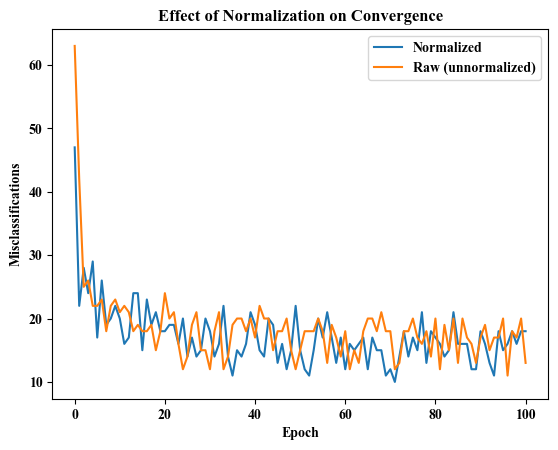

In [ ]:
# Without normalization
X_train_raw, X_test_raw, y_train_r, y_test_r = train_test_split(
    df.drop('Target', axis=1).values, df['Target'].values, test_size=0.2, random_state=42
)

w_raw = np.zeros(4)
b_raw = 0
error_hist_raw = []

for i in range(epochs+1):
    mistake = 0
    for j in range(len(X_train_raw)):
        z = np.dot(X_train_raw[j], w_raw) + b_raw
        y_pred = Stepfn(z)
        error = y_train_r[j] - y_pred
        if error != 0:
            mistake += 1
        w_raw = w_raw + learning_rate*error*X_train_raw[j]
        b_raw = b_raw + learning_rate*error
    error_hist_raw.append(mistake)

# Plot both for comparison
plt.figure()
plt.plot(error_hist, label="Normalized")
plt.plot(error_hist_raw, label="Raw (unnormalized)")
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.legend()
plt.title("Effect of Normalization on Convergence")
plt.savefig("normalization_comparison.eps", dpi=600, format="eps")
plt.show()